In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning

from astropy.table import Table

# Carga inicial del catálogo astronómico
tab = Table.read("dr7MPA_WISE_WISC.fits")  # Ajustá al nombre exacto de tu archivo FITS
df = tab.to_pandas()

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==============================================================================
# 1. DEFINICIÓN DE VARIABLES Y LIMPIEZA
# ==============================================================================
target_col = "SSFR_MEDIAN"  # Cambiar a "SMASS_MEDIAN" si se vuelve a masa
calpha_cols = [f"CALPHA_{i}" for i in range(1, 8)]
mag_cols = ["MODELU", "MODELG", "MODELR", "MODELI", "MODELZ"]

# Identificar columna de Redshift ('Z' o 'z')
z_col = "Z" if "Z" in df.columns else "z"

# Selección de columnas requeridas
required_cols = list(set([target_col, z_col, "MODELR"] + mag_cols + calpha_cols))
work = df.loc[:, required_cols].copy()

# Tratamiento de valores infinitos y nulos
work = work.replace([np.inf, -np.inf], np.nan).dropna()

# Filtro físico según la variable objetivo
if target_col == "SSFR_MEDIAN":
    work = work[(work[target_col] >= -13.0) & (work[target_col] <= -8.0)]
else:
    work = work[(work[target_col] >= 7.0) & (work[target_col] <= 12.5)]

# Ingeniería de variables: Colores
work["u_g"] = work["MODELU"] - work["MODELG"]
work["g_r"] = work["MODELG"] - work["MODELR"]
work["r_i"] = work["MODELR"] - work["MODELI"]
work["i_z"] = work["MODELI"] - work["MODELZ"]

# ==============================================================================
# SUBMUESTRA DE PRUEBA RÁPIDA (Dry Run) -> COLOCAR ACÁ
# ==============================================================================
# Comentá o borrá esta línea cuando vayas a hacer la corrida definitiva:
#work = work.sample(n=10000, random_state=1234)

print(f"Muestra lista para evaluación: {len(work)} galaxias")

# ==============================================================================
# 2. DEFINICIÓN DE LOS 4 CONJUNTOS DE FEATURES
# ==============================================================================
foto_cols = ["u_g", "g_r", "r_i", "i_z", "MODELR"]

feature_sets = {
    "Solo_Fotometria": foto_cols,
    "Fotometria_y_PCA": foto_cols + calpha_cols,
    "Fotometria_y_Redshift": foto_cols + [z_col],
    "Foto_Espectro_Redshift": foto_cols + [z_col] + calpha_cols
}

# ==============================================================================
# 3. PARTICIÓN TRAIN / TEST UNIFICADA
# ==============================================================================
idx_train, idx_test = train_test_split(work.index, test_size=0.2, random_state=1234)
y_train = work.loc[idx_train, target_col]
y_test = work.loc[idx_test, target_col]

# Fábrica de modelos
def crear_modelos():
    return {
        "Baseline": DummyRegressor(strategy="mean"),
        "RandomForest": RandomForestRegressor(
            n_estimators=100, min_samples_leaf=10, max_depth=20, random_state=1234, n_jobs=-1
        ),
        "MLP": make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(128, 64),   # Mayor capacidad para absorber el catálogo masivo
        activation="relu",
        solver="adam",
        alpha=0.001,                    # Regularización L2 equilibrada
        max_iter=500,                   # Límite amplio de iteraciones
        early_stopping=True,            # Detención automática al converger
        n_iter_no_change=20,            # Margen de espera prudente antes de cortar
        random_state=1234
    )
)
    }

# ==============================================================================
# 4. ENTRENAMIENTO Y EVALUACIÓN ITERATIVA
# ==============================================================================
resultados = []
predicciones = {}

for set_name, feats in feature_sets.items():
    print(f"\n" + "=" * 65)
    print(f"Conjunto de features: {set_name} -> {feats}")
    print("=" * 65)
    
    X_train_sub = work.loc[idx_train, feats]
    X_test_sub = work.loc[idx_test, feats]
    
    modelos = crear_modelos()
    print(f"{'Modelo':<15} {'MAE':<10} {'RMSE':<10} {'R2':<10}")
    
    for mod_name, model in modelos.items():
        model.fit(X_train_sub, y_train)
        pred = model.predict(X_test_sub)
        
        # Guardar predicciones para análisis posteriores o gráficos
        predicciones[(set_name, mod_name)] = pred
        
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        
        resultados.append({
            "Conjunto": set_name,
            "Modelo": mod_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })
        print(f"{mod_name:<15} {mae:<10.4f} {rmse:<10.4f} {r2:<10.4f}")

# ==============================================================================
# 5. TABLA RESUMEN CONSOLIDADA
# ==============================================================================
df_metricas = pd.DataFrame(resultados)
print("\n" + "=" * 65)
print("RESUMEN GLOBAL DE RENDIMIENTO")
print("=" * 65)
print(df_metricas.to_string(index=False))

Muestra lista para evaluación: 778782 galaxias

Conjunto de features: Solo_Fotometria -> ['u_g', 'g_r', 'r_i', 'i_z', 'MODELR']
Modelo          MAE        RMSE       R2        
Baseline        0.8062     0.8969     -0.0000   
RandomForest    0.1904     0.2925     0.8937    
MLP             0.1993     0.3029     0.8860    

Conjunto de features: Fotometria_y_PCA -> ['u_g', 'g_r', 'r_i', 'i_z', 'MODELR', 'CALPHA_1', 'CALPHA_2', 'CALPHA_3', 'CALPHA_4', 'CALPHA_5', 'CALPHA_6', 'CALPHA_7']
Modelo          MAE        RMSE       R2        
Baseline        0.8062     0.8969     -0.0000   
RandomForest    0.1550     0.2458     0.9249    
MLP             0.2070     0.3035     0.8855    

Conjunto de features: Fotometria_y_Redshift -> ['u_g', 'g_r', 'r_i', 'i_z', 'MODELR', 'Z']
Modelo          MAE        RMSE       R2        
Baseline        0.8062     0.8969     -0.0000   
RandomForest    0.1637     0.2653     0.9125    
MLP             0.1707     0.2711     0.9086    

Conjunto de features: Fot

In [4]:
import numpy as np
import pandas as pd

# Calculamos el Bias (y_real - y_pred) para cada modelo y conjunto ya guardados
datos_bias = []

for (set_name, mod_name), pred in predicciones.items():
    residuos = y_test - pred
    bias_valor = np.mean(residuos)
    
    datos_bias.append({
        "Conjunto": set_name,
        "Modelo": mod_name,
        "Bias (dex)": bias_valor
    })

df_bias = pd.DataFrame(datos_bias)

# Unir con la tabla de métricas que ya tenías
df_metricas_completo = pd.merge(df_metricas, df_bias, on=["Conjunto", "Modelo"])

print("=" * 70)
print("TABLA CONSOLIDADA CON BIAS")
print("=" * 70)
print(df_metricas_completo.to_string(index=False))

TABLA CONSOLIDADA CON BIAS
              Conjunto       Modelo      MAE     RMSE            R2  Bias (dex)
       Solo_Fotometria     Baseline 0.806230 0.896918 -1.192093e-07   -0.000069
       Solo_Fotometria RandomForest 0.190375 0.292461  8.936763e-01    0.000570
       Solo_Fotometria          MLP 0.199316 0.302891  8.859575e-01    0.008773
      Fotometria_y_PCA     Baseline 0.806230 0.896918 -1.192093e-07   -0.000069
      Fotometria_y_PCA RandomForest 0.155008 0.245813  9.248891e-01   -0.000117
      Fotometria_y_PCA          MLP 0.207002 0.303536  8.854714e-01    0.009345
 Fotometria_y_Redshift     Baseline 0.806230 0.896918 -1.192093e-07   -0.000069
 Fotometria_y_Redshift RandomForest 0.163733 0.265328  9.124897e-01    0.000840
 Fotometria_y_Redshift          MLP 0.170740 0.271133  9.086186e-01   -0.011272
Foto_Espectro_Redshift     Baseline 0.806230 0.896918 -1.192093e-07   -0.000069
Foto_Espectro_Redshift RandomForest 0.147425 0.239965  9.284202e-01   -0.000102
Foto_Espectro

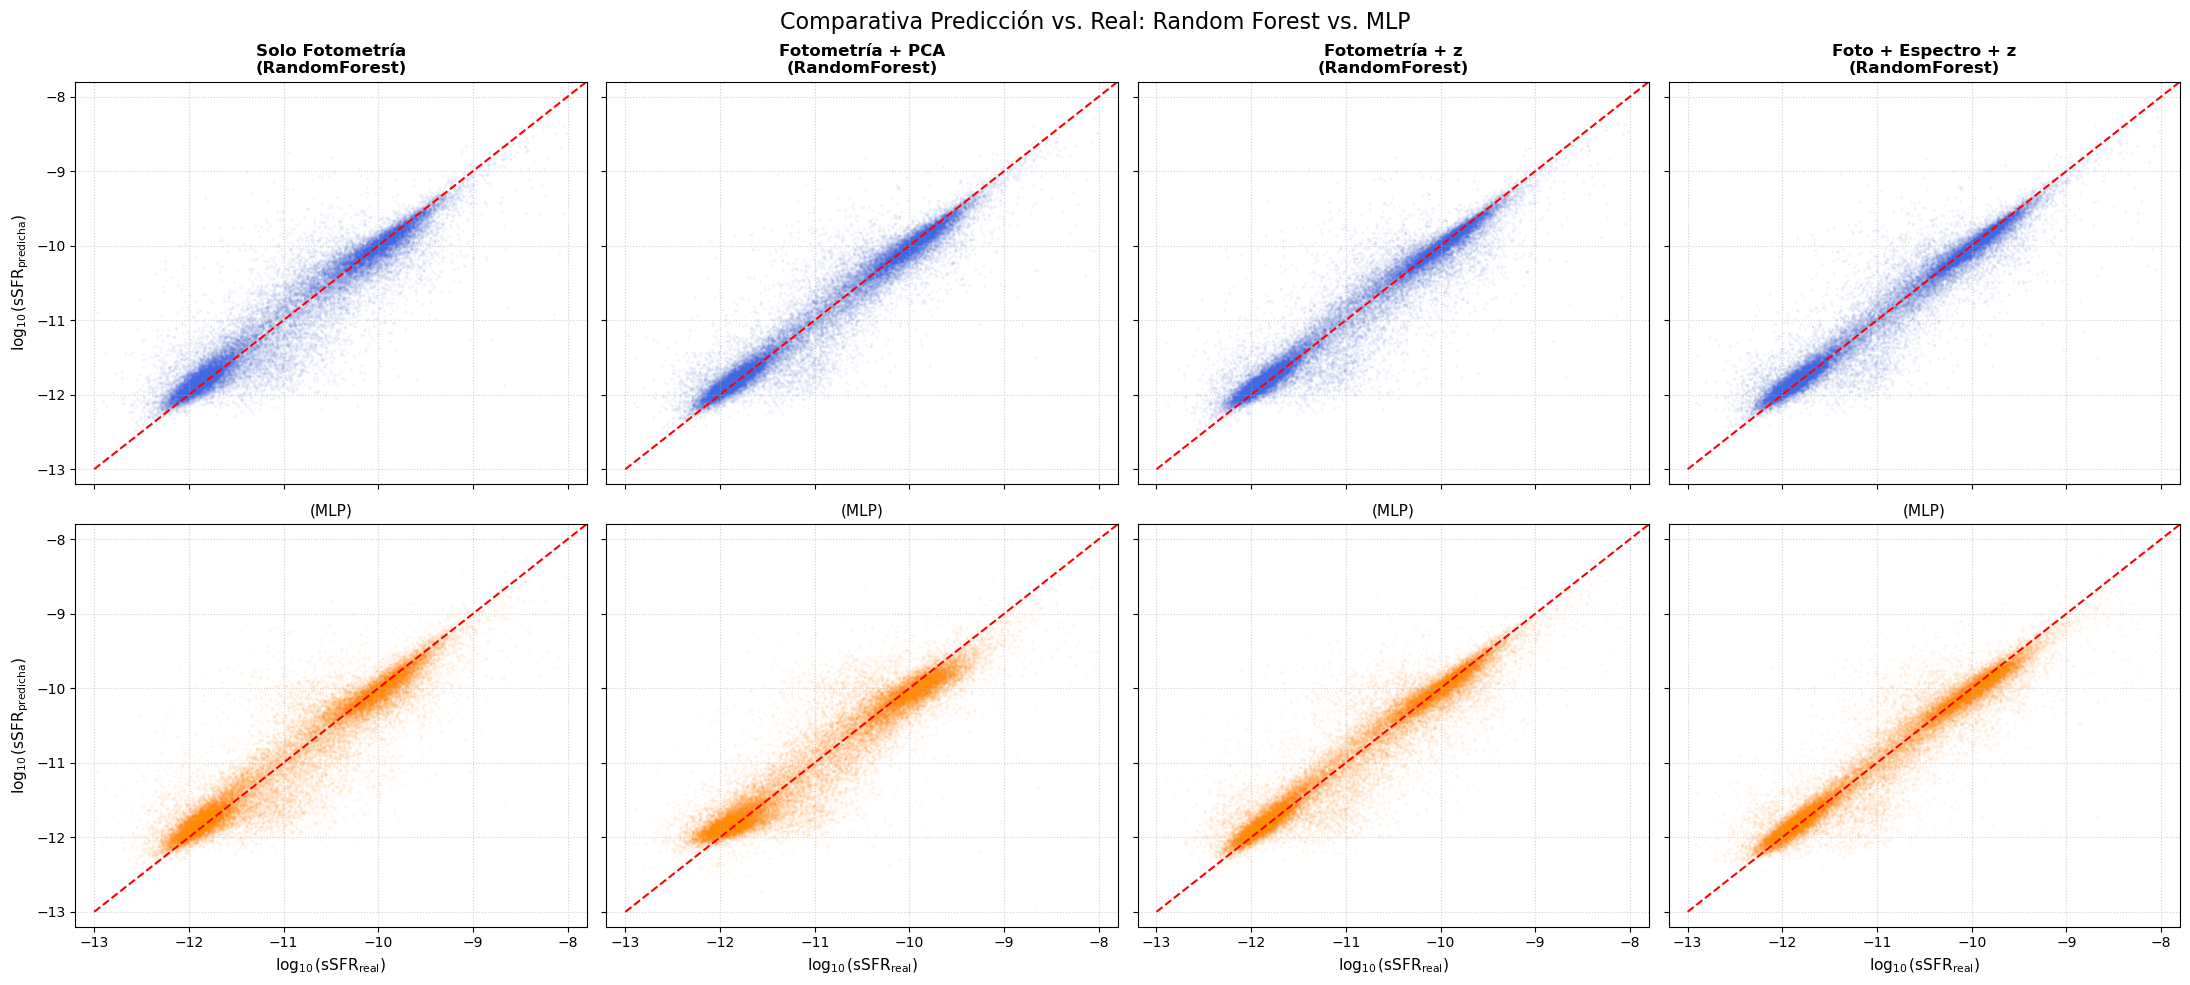

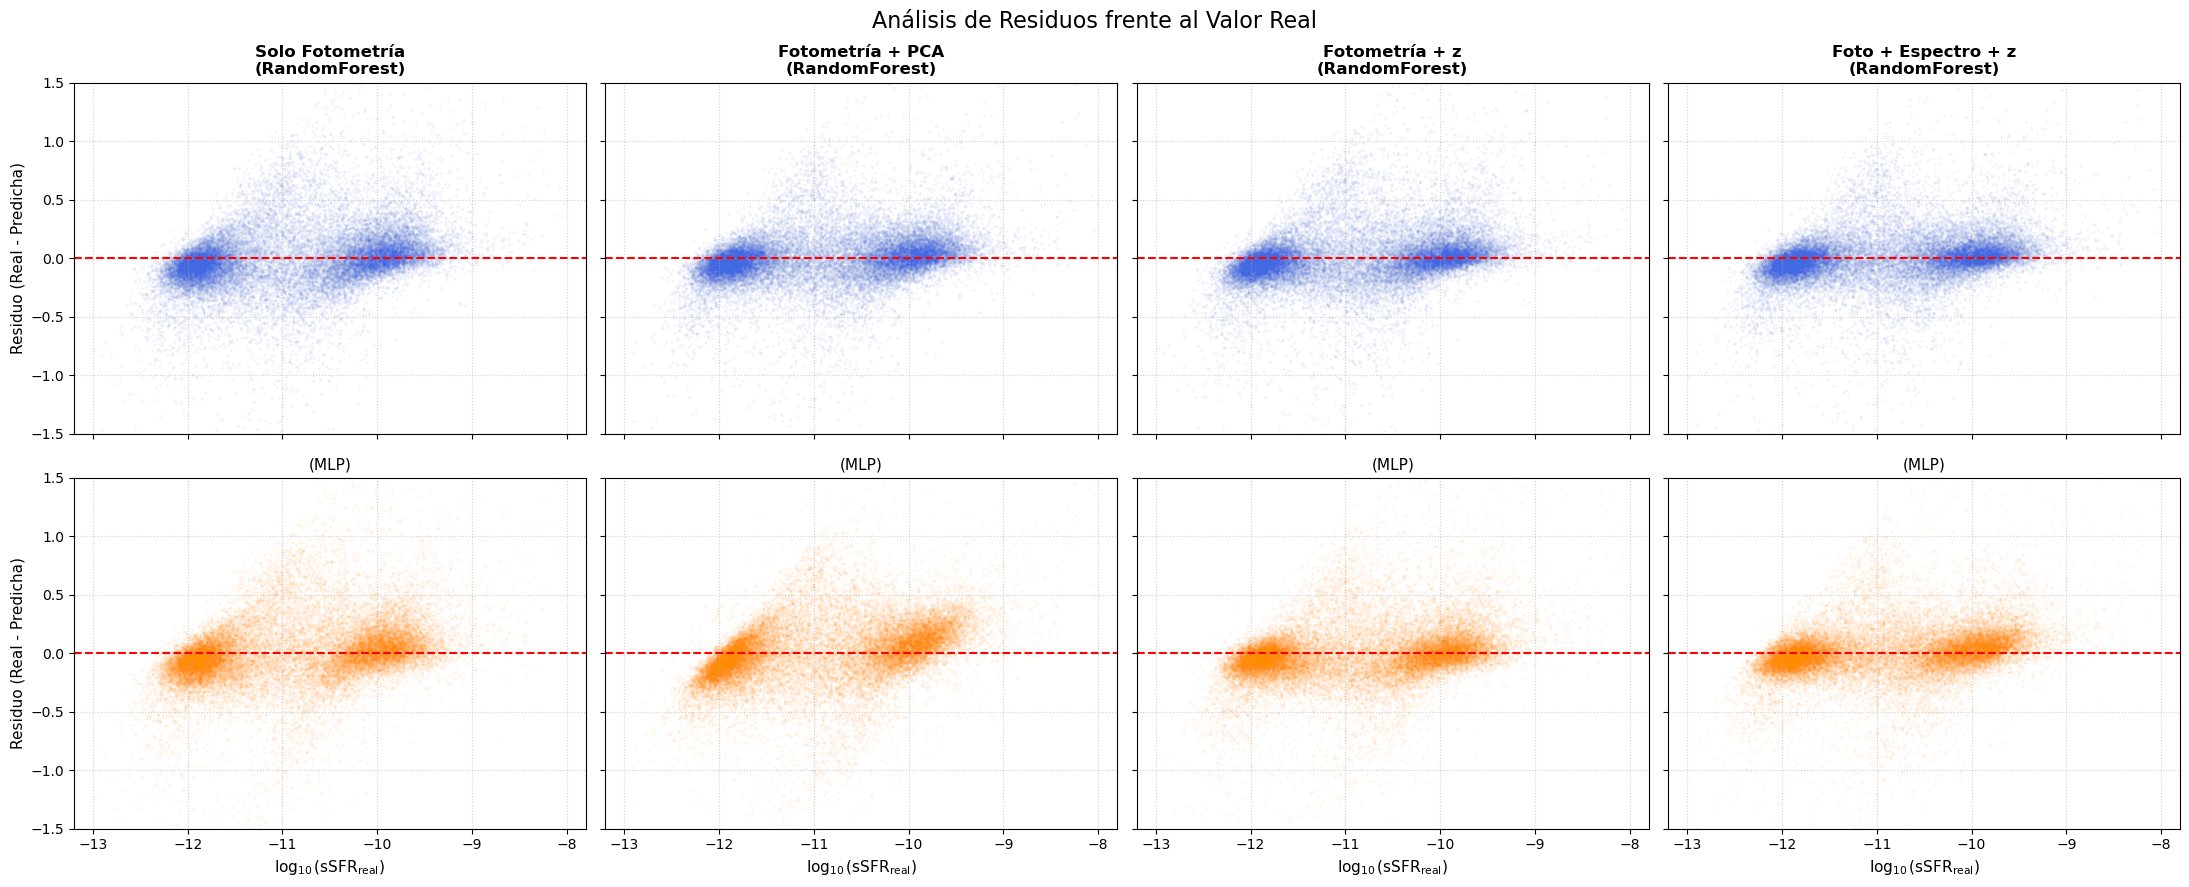

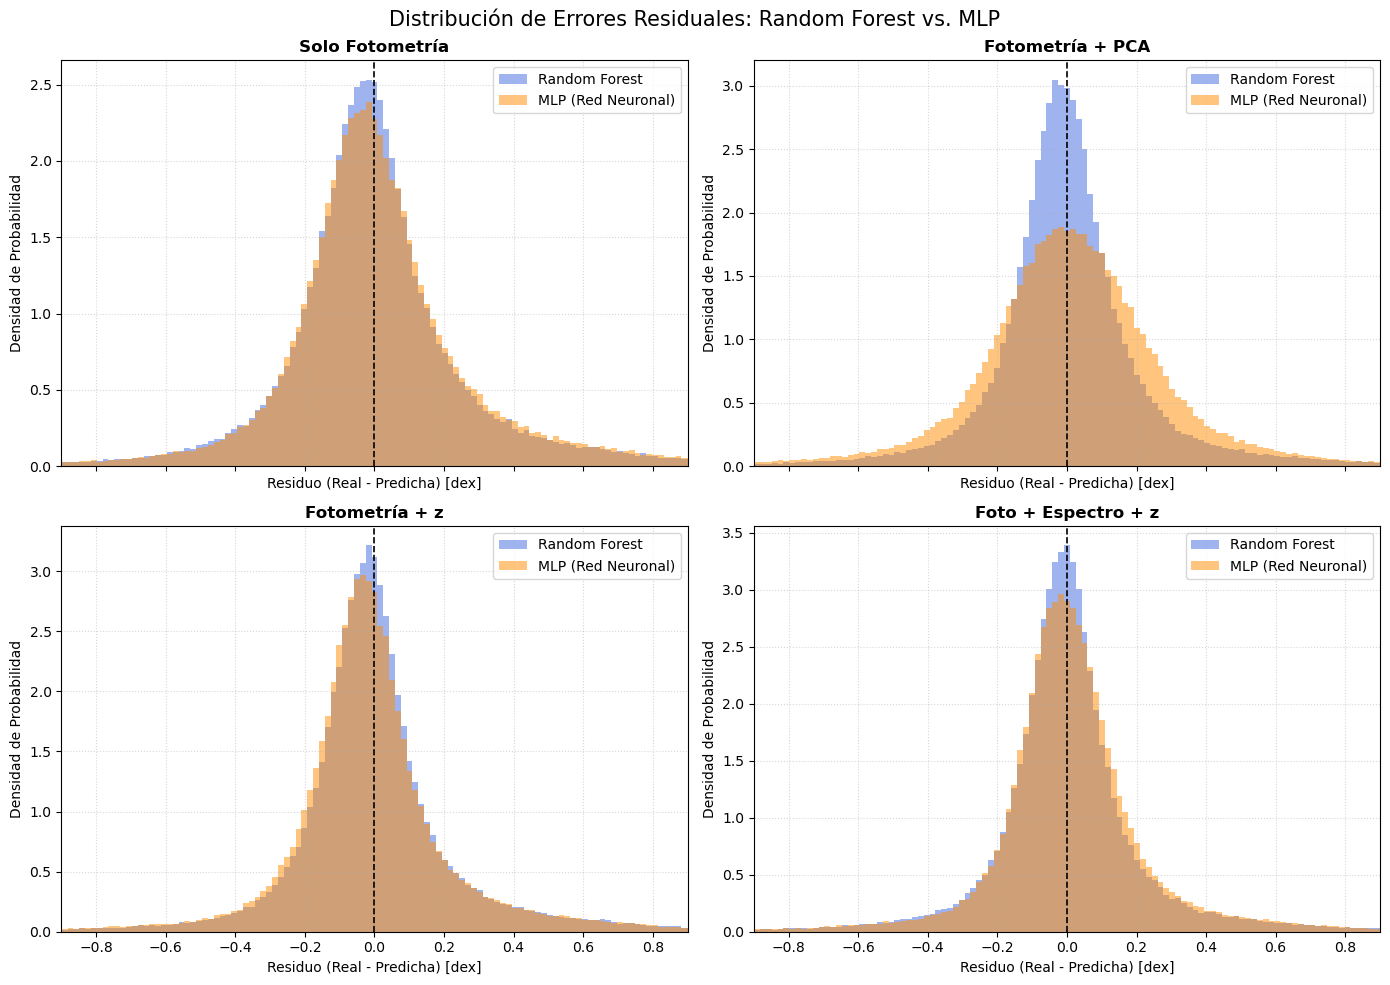

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres y orden de los 4 espacios de variables
nombres_conjuntos = [
    "Solo_Fotometria",
    "Fotometria_y_PCA",
    "Fotometria_y_Redshift",
    "Foto_Espectro_Redshift"
]
titulos = [
    "Solo Fotometría",
    "Fotometría + PCA",
    "Fotometría + z",
    "Foto + Espectro + z"
]

# Para graficar scatter de 155k puntos sin congelar Jupyter,
# tomamos una muestra aleatoria de 25.000 galaxias para el renderizado
np.random.seed(1234)
idx_plot = np.random.choice(len(y_test), size=min(25000, len(y_test)), replace=False)
y_real_sub = y_test.iloc[idx_plot].values

# ==============================================================================
# FIGURA 1: COMPARATIVA DISPERSIÓN PREDICHO VS REAL (GRILLA 2x4)
# ==============================================================================
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)

modelos_eval = ["RandomForest", "MLP"]
colores_modelo = {"RandomForest": "royalblue", "MLP": "darkorange"}

for row_idx, mod_name in enumerate(modelos_eval):
    for col_idx, (set_name, tit) in enumerate(zip(nombres_conjuntos, titulos)):
        ax = axes[row_idx, col_idx]
        
        y_pred = predicciones[(set_name, mod_name)]
        y_pred_sub = y_pred[idx_plot]
        
        # Dispersión con transparencia para apreciar la bimodalidad
        ax.scatter(y_real_sub, y_pred_sub, alpha=0.04, s=2, color=colores_modelo[mod_name], rasterized=True)
        
        # Línea 1:1 ideal
        ax.plot([-13, -7], [-13, -7], 'r--', lw=1.5, label='Línea 1:1')
        
        if row_idx == 0:
            ax.set_title(f"{tit}\n({mod_name})", fontsize=12, fontweight='bold')
        else:
            ax.set_title(f"({mod_name})", fontsize=11)
            
        if col_idx == 0:
            ax.set_ylabel(r"$\log_{10}(\mathrm{sSFR}_{\mathrm{predicha}})$", fontsize=11)
        if row_idx == 1:
            ax.set_xlabel(r"$\log_{10}(\mathrm{sSFR}_{\mathrm{real}})$", fontsize=11)
            
        ax.set_xlim(-13.2, -7.8)
        ax.set_ylim(-13.2, -7.8)
        ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Comparativa Predicción vs. Real: Random Forest vs. MLP", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig("plot_1_dispersion_pred_vs_real.png", dpi=300, bbox_inches="tight")
plt.show()

# ==============================================================================
# FIGURA 2: RESIDUOS (REAL - PREDICHO) VS REAL (GRILLA 2x4)
# ==============================================================================
fig2, axes2 = plt.subplots(2, 4, figsize=(22, 9), sharex=True, sharey=True)

for row_idx, mod_name in enumerate(modelos_eval):
    for col_idx, (set_name, tit) in enumerate(zip(nombres_conjuntos, titulos)):
        ax = axes2[row_idx, col_idx]
        
        y_pred = predicciones[(set_name, mod_name)]
        residuos_sub = y_real_sub - y_pred[idx_plot]
        
        ax.scatter(y_real_sub, residuos_sub, alpha=0.04, s=2, color=colores_modelo[mod_name], rasterized=True)
        ax.axhline(0, color='red', linestyle='--', lw=1.5)
        
        if row_idx == 0:
            ax.set_title(f"{tit}\n({mod_name})", fontsize=12, fontweight='bold')
        else:
            ax.set_title(f"({mod_name})", fontsize=11)
            
        if col_idx == 0:
            ax.set_ylabel("Residuo (Real - Predicha)", fontsize=11)
        if row_idx == 1:
            ax.set_xlabel(r"$\log_{10}(\mathrm{sSFR}_{\mathrm{real}})$", fontsize=11)
            
        ax.set_xlim(-13.2, -7.8)
        ax.set_ylim(-1.5, 1.5)
        ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Análisis de Residuos frente al Valor Real", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig("plot_2_residuos_vs_real.png", dpi=300, bbox_inches="tight")
plt.show()

# ==============================================================================
# FIGURA 3: HISTOGRAMAS DE RESIDUOS SUPERPUESTOS (RF vs MLP)
# ==============================================================================
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes_flat = axes3.flatten()

bins = np.linspace(-1.0, 1.0, 120)

for i, (set_name, tit) in enumerate(zip(nombres_conjuntos, titulos)):
    ax = axes_flat[i]
    
    res_rf = y_test.values - predicciones[(set_name, "RandomForest")]
    res_mlp = y_test.values - predicciones[(set_name, "MLP")]
    
    # Histograma usando el 100% de las 155k galaxias de prueba
    ax.hist(res_rf, bins=bins, density=True, alpha=0.5, color='royalblue', label='Random Forest', edgecolor='none')
    ax.hist(res_mlp, bins=bins, density=True, alpha=0.5, color='darkorange', label='MLP (Red Neuronal)', edgecolor='none')
    
    ax.axvline(0, color='black', linestyle='--', lw=1.2)
    ax.set_title(tit, fontsize=12, fontweight='bold')
    ax.set_xlabel("Residuo (Real - Predicha) [dex]", fontsize=10)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=10)
    ax.set_xlim(-0.9, 0.9)
    ax.legend(loc="upper right")
    ax.grid(True, linestyle=":", alpha=0.5)

plt.suptitle("Distribución de Errores Residuales: Random Forest vs. MLP", fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig("plot_3_distribucion_residuos.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
import pickle

# 1. Guardar diccionario de predicciones en disco
with open("predicciones_modelos.pkl", "wb") as f:
    pickle.dump(predicciones, f)

# 2. Guardar el conjunto de test real
y_test.to_pickle("y_test_sSFR.pkl")

# 3. Guardar la tabla comparativa con métricas y Bias
df_metricas_completo.to_csv("metricas_globales_con_bias.csv", index=False)

print("Datos guardados exitosamente en el disco.")

Datos guardados exitosamente en el disco.


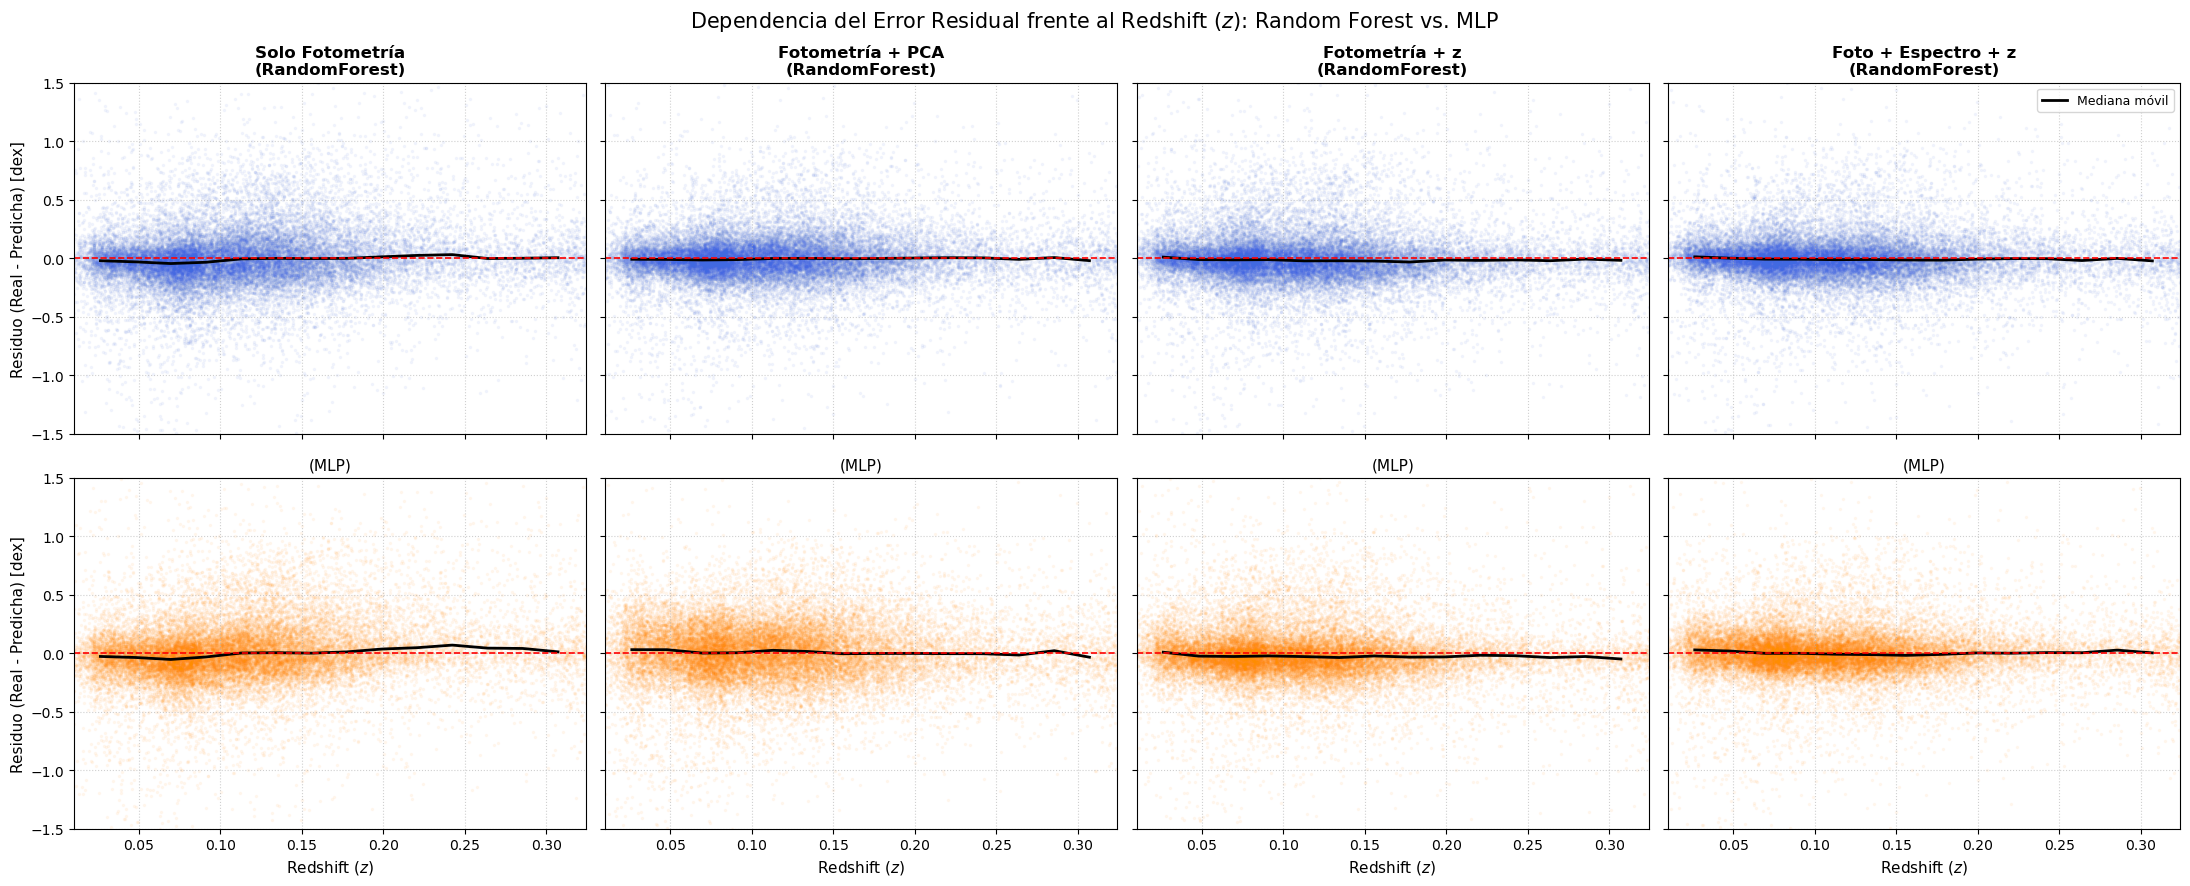

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Recuperar el vector de Redshift para el conjunto de prueba
col_z = "Z" if "Z" in work.columns else "z"
z_test_vals = work.loc[idx_test, col_z].values

# Submuestra representativa de 25.000 galaxias para visualización fluida
np.random.seed(1234)
idx_plot_z = np.random.choice(len(y_test), size=min(25000, len(y_test)), replace=False)

z_sub = z_test_vals[idx_plot_z]
y_real_sub_z = y_test.iloc[idx_plot_z].values

# Conjuntos y títulos correspondientes
nombres_conjuntos = [
    "Solo_Fotometria",
    "Fotometria_y_PCA",
    "Fotometria_y_Redshift",
    "Foto_Espectro_Redshift"
]
titulos = [
    "Solo Fotometría",
    "Fotometría + PCA",
    "Fotometría + z",
    "Foto + Espectro + z"
]

modelos_eval = ["RandomForest", "MLP"]
colores = {"RandomForest": "royalblue", "MLP": "darkorange"}

# 2. Configuración de la figura (2 filas x 4 columnas)
fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharex=True, sharey=True)

# Bins de redshift para trazar la mediana del residuo móvil
bins_z = np.linspace(np.percentile(z_sub, 1), np.percentile(z_sub, 99), 15)
bin_centers = 0.5 * (bins_z[:-1] + bins_z[1:])

for row_idx, mod_name in enumerate(modelos_eval):
    for col_idx, (set_name, tit) in enumerate(zip(nombres_conjuntos, titulos)):
        ax = axes[row_idx, col_idx]
        
        y_pred = predicciones[(set_name, mod_name)]
        residuos = y_real_sub_z - y_pred[idx_plot_z]
        
        # Dispersión con transparencia
        ax.scatter(z_sub, residuos, alpha=0.05, s=2.5, color=colores[mod_name], rasterized=True)
        
        # Cálculo de la mediana del residuo en función de z
        df_temp = pd.DataFrame({"z": z_sub, "res": residuos})
        df_temp["bin"] = pd.cut(df_temp["z"], bins=bins_z)
        mediana_res = df_temp.groupby("bin", observed=False)["res"].median().values
        
        # Curva de tendencia local y línea horizontal de sesgo nulo
        ax.plot(bin_centers, mediana_res, color="black", lw=2, label="Mediana móvil")
        ax.axhline(0, color="red", linestyle="--", lw=1.2)
        
        if row_idx == 0:
            ax.set_title(f"{tit}\n({mod_name})", fontsize=12, fontweight="bold")
        else:
            ax.set_title(f"({mod_name})", fontsize=11)
            
        if col_idx == 0:
            ax.set_ylabel("Residuo (Real - Predicha) [dex]", fontsize=11)
        if row_idx == 1:
            ax.set_xlabel("Redshift ($z$)", fontsize=11)
            
        ax.set_ylim(-1.5, 1.5)
        ax.set_xlim(np.percentile(z_sub, 0.5), np.percentile(z_sub, 99.5))
        ax.grid(True, linestyle=":", alpha=0.6)
        if row_idx == 0 and col_idx == 3:
            ax.legend(loc="upper right", fontsize=9)

plt.suptitle("Dependencia del Error Residual frente al Redshift ($z$): Random Forest vs. MLP", fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig("plot_4_residuos_vs_redshift.png", dpi=300, bbox_inches="tight")
plt.show()

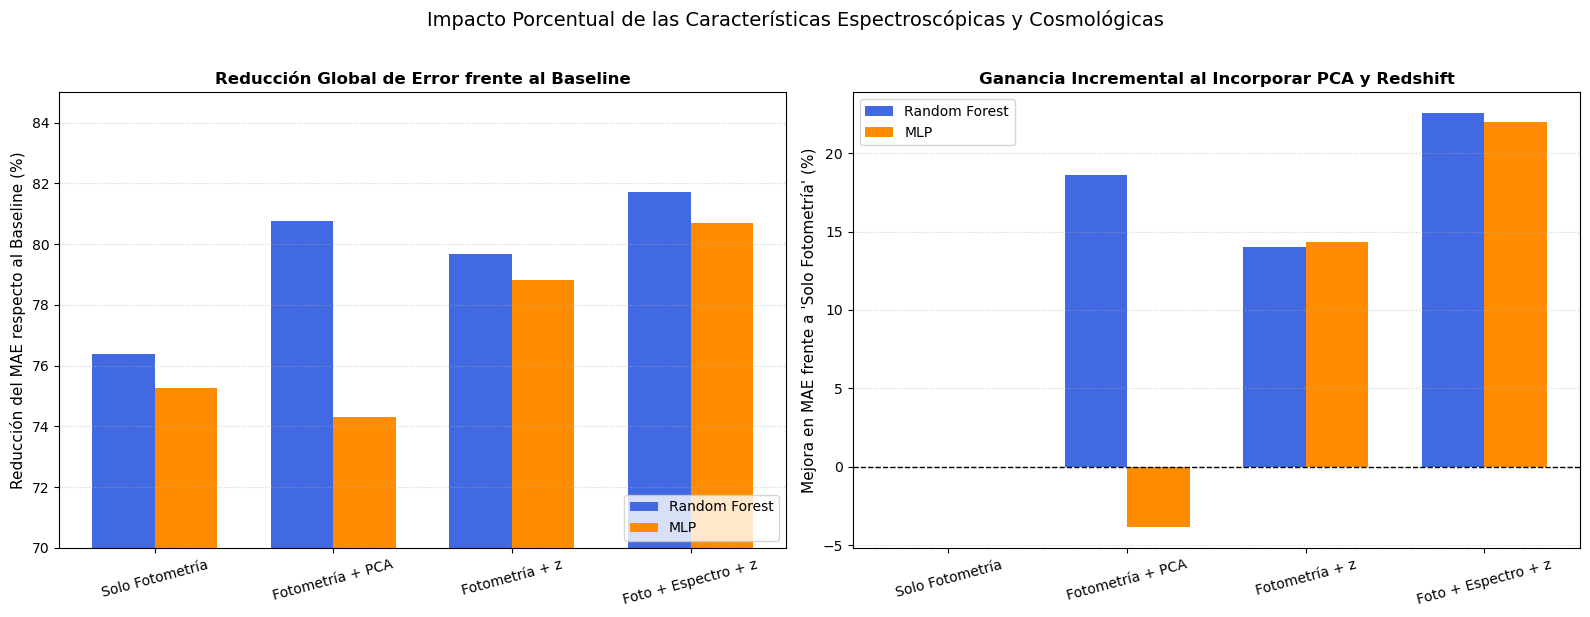

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Recuperar valores base del Baseline
mae_base = df_metricas_completo.loc[df_metricas_completo["Modelo"] == "Baseline", "MAE"].iloc[0]
rmse_base = df_metricas_completo.loc[df_metricas_completo["Modelo"] == "Baseline", "RMSE"].iloc[0]

# 2. Filtrar solo los modelos predictivos (RF y MLP)
df_ganancia = df_metricas_completo[df_metricas_completo["Modelo"] != "Baseline"].copy()

# Reducción porcentual respecto al Baseline
df_ganancia["Reduccion_MAE_%"] = ((mae_base - df_ganancia["MAE"]) / mae_base) * 100.0
df_ganancia["Reduccion_RMSE_%"] = ((rmse_base - df_ganancia["RMSE"]) / rmse_base) * 100.0

# Ganancia porcentual relativa a 'Solo Fotometría' dentro de cada modelo
ganancias_mae_foto = []
ganancias_rmse_foto = []

for idx, row in df_ganancia.iterrows():
    mod = row["Modelo"]
    mae_ref_foto = df_ganancia.loc[(df_ganancia["Modelo"] == mod) & (df_ganancia["Conjunto"] == "Solo_Fotometria"), "MAE"].iloc[0]
    rmse_ref_foto = df_ganancia.loc[(df_ganancia["Modelo"] == mod) & (df_ganancia["Conjunto"] == "Solo_Fotometria"), "RMSE"].iloc[0]
    
    g_mae = ((mae_ref_foto - row["MAE"]) / mae_ref_foto) * 100.0
    g_rmse = ((rmse_ref_foto - row["RMSE"]) / rmse_ref_foto) * 100.0
    
    ganancias_mae_foto.append(g_mae)
    ganancias_rmse_foto.append(g_rmse)

df_ganancia["Ganancia_MAE_vs_Foto_%"] = ganancias_mae_foto
df_ganancia["Ganancia_RMSE_vs_Foto_%"] = ganancias_rmse_foto

# ==============================================================================
# 4. GRÁFICO COMPARATIVO DE GANANCIA PORCENTUAL
# ==============================================================================
conjuntos_labels = ["Solo Fotometría", "Fotometría + PCA", "Fotometría + z", "Foto + Espectro + z"]
x = np.arange(len(conjuntos_labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Reducción respecto al Baseline
rf_red = df_ganancia[df_ganancia["Modelo"] == "RandomForest"]["Reduccion_MAE_%"].values
mlp_red = df_ganancia[df_ganancia["Modelo"] == "MLP"]["Reduccion_MAE_%"].values

ax1.bar(x - width/2, rf_red, width, label="Random Forest", color="royalblue")
ax1.bar(x + width/2, mlp_red, width, label="MLP", color="darkorange")
ax1.set_ylabel("Reducción del MAE respecto al Baseline (%)", fontsize=11)
ax1.set_title("Reducción Global de Error frente al Baseline", fontsize=12, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(conjuntos_labels, rotation=15, fontsize=10)
ax1.set_ylim(70, 85)
ax1.grid(axis="y", linestyle=":", alpha=0.6)
ax1.legend(loc="lower right")

# Panel 2: Ganancia neta frente a Solo Fotometría
rf_gain = df_ganancia[df_ganancia["Modelo"] == "RandomForest"]["Ganancia_MAE_vs_Foto_%"].values
mlp_gain = df_ganancia[df_ganancia["Modelo"] == "MLP"]["Ganancia_MAE_vs_Foto_%"].values

ax2.bar(x - width/2, rf_gain, width, label="Random Forest", color="royalblue")
ax2.bar(x + width/2, mlp_gain, width, label="MLP", color="darkorange")
ax2.axhline(0, color="black", linestyle="--", lw=1)
ax2.set_ylabel("Mejora en MAE frente a 'Solo Fotometría' (%)", fontsize=11)
ax2.set_title("Ganancia Incremental al Incorporar PCA y Redshift", fontsize=12, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(conjuntos_labels, rotation=15, fontsize=10)
ax2.grid(axis="y", linestyle=":", alpha=0.6)
ax2.legend(loc="upper left")

plt.suptitle("Impacto Porcentual de las Características Espectroscópicas y Cosmológicas", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plot_5_ganancia_porcentual.png", dpi=300, bbox_inches="tight")
plt.show()